[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/gaia/2026-07-30-hr-diagram-ngc188/notebook.ipynb)

# An HR diagram for NGC 188, one of the oldest nearby open clusters

NGC 188 is an open star cluster that's unusually old for its type -- around 6-7 billion years, far older than the Pleiades or Hyades -- which makes it a good target to see how an HR diagram (brightness vs. color) changes shape as a cluster ages. I built one from real Gaia data and compared what I saw here to the two younger clusters I looked at earlier in this folder.

In [1]:
from astroquery.gaia import Gaia
import numpy as np
import matplotlib.pyplot as plt

Gaia.ROW_LIMIT = 3000
query = '''
SELECT source_id, parallax, phot_g_mean_mag, bp_rp
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 11.8, 85.25, 0.3))
AND parallax BETWEEN 0.4 AND 0.7
AND phot_g_mean_mag IS NOT NULL AND bp_rp IS NOT NULL
'''
job = Gaia.launch_job(query)
tab = job.get_results()
print(len(tab), 'likely NGC 188 members retrieved')

1709 likely NGC 188 members retrieved


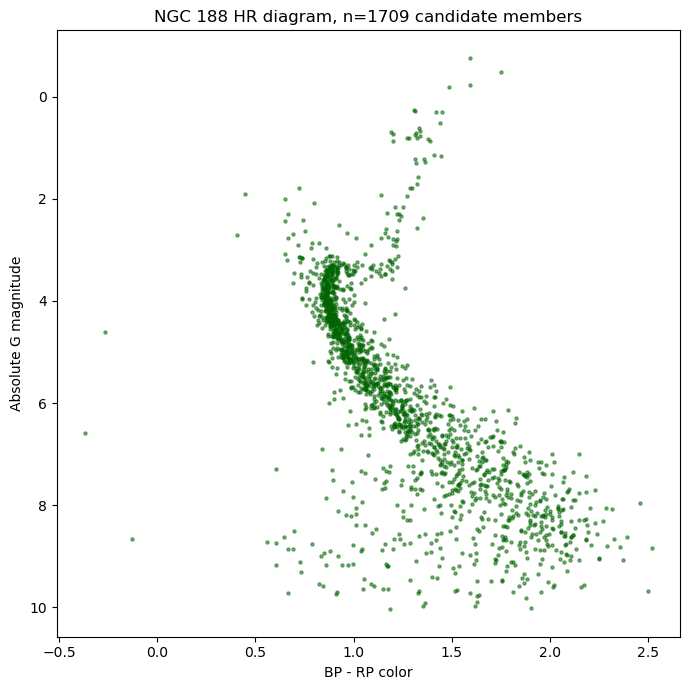

In [2]:
parallax = np.array(tab['parallax'])
g_mag = np.array(tab['phot_g_mean_mag'])
bp_rp = np.array(tab['bp_rp'])
distance_pc = 1000.0/parallax
abs_mag = g_mag - 5*np.log10(distance_pc) + 5

plt.figure(figsize=(7,7))
plt.scatter(bp_rp, abs_mag, s=5, alpha=0.5, color='darkgreen')
plt.gca().invert_yaxis()
plt.xlabel('BP - RP color')
plt.ylabel('Absolute G magnitude')
plt.title(f'NGC 188 HR diagram, n={len(tab)} candidate members')
plt.tight_layout()
plt.savefig('hr_ngc188.png', dpi=120)
plt.show()

The main sequence here is noticeably shorter at the bright end than in the Pleiades or Hyades diagrams, and there's a visible clump of redder, brighter stars sitting above it -- red giants, stars that have already evolved off the main sequence. That combination (a low 'turn-off' point plus a populated giant branch) is exactly the signature of an old cluster.

**What I'd look at next:** Estimate an actual age for NGC 188 by comparing where its main sequence turn-off sits against theoretical stellar evolution models (isochrones).

**Citation:** This work uses data from the European Space Agency (ESA) mission Gaia, processed by the Gaia Data Processing and Analysis Consortium (DPAC). See https://www.cosmos.esa.int/web/gaia/credits.